In [1]:
!pip install gdown  # Ensure gdown is installed

In [2]:
import gdown

# Replace FILE_ID with your actual file ID
file_id = "1xTMWJ3tIzrjMyLZhjgGBGtzWAo5b1X8Y"
output_file = "Brain_Tumor_Segmentation_Datasets.zip"

# Download the file
gdown.download(f"https://drive.google.com/uc?id={file_id}", output_file, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1xTMWJ3tIzrjMyLZhjgGBGtzWAo5b1X8Y
From (redirected): https://drive.google.com/uc?id=1xTMWJ3tIzrjMyLZhjgGBGtzWAo5b1X8Y&confirm=t&uuid=3bc7c635-f1f0-4633-818d-ca4843637ea6
To: /content/Brain_Tumor_Segmentation_Datasets.zip
100%|██████████| 47.4M/47.4M [00:02<00:00, 18.9MB/s]


'Brain_Tumor_Segmentation_Datasets.zip'

In [3]:
import zipfile
z = zipfile.ZipFile('/content/Brain_Tumor_Segmentation_Datasets.zip')
z.extractall()

In [4]:
import os
import shutil

src = 'Brain_Tumor_Segmentation_Datasets'
dst_dir = 'datasets'
dst = os.path.join(dst_dir, src)

# Create 'datasets' directory if it doesn't exist
os.makedirs(dst_dir, exist_ok=True)

# If 'pothole_datasets' already exists in 'datasets', remove it
if os.path.exists(dst):
    shutil.rmtree(dst)

# Move 'pothole_datasets' to 'datasets'
shutil.move(src, dst)

print(f"Moved '{src}' to '{dst}' successfully.")


Moved 'Brain_Tumor_Segmentation_Datasets' to 'datasets/Brain_Tumor_Segmentation_Datasets' successfully.


## **Importing libraries**

In [5]:
import yaml

# Define YAML configuration
data = {
    'path': 'Brain_Tumor_Segmentation_Datasets',
    'train': 'train/images',
    'val': 'valid/images',
    'nc': 1,
    'names': ['Tumor']
}

# Save to pothole.yaml
with open('Brain_Tumor_Segmentation_Datasets.yaml', 'w') as file:
    yaml.dump(data, file, default_flow_style=False)

print("Brain_Tumor_Segmentation_Datasets.yaml created successfully!")


Brain_Tumor_Segmentation_Datasets.yaml created successfully!


In [6]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 117.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 96.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 58.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 94.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

In [7]:
from ultralytics import YOLO

# Load a pretrained YOLOv9 segmentation model
model = YOLO('yolov9e-seg.pt')

# Train the model with data augmentation
model.train(
    data='Brain_Tumor_Segmentation_Datasets.yaml',
    epochs=50,
    imgsz=640,
    batch=8,
    name='Brain_Tumor_Segmentation_Datasets_yolov8',
    save=True,
    save_period=-1,
    patience=20,
    val=True,
    augment=True,  # Enables default augmentations
    degrees=10.0,  # Rotation
    translate=0.1,  # Translation
    scale=0.5,  # Scaling
    shear=2.0,  # Shearing
    perspective=0.0005,  # Perspective
    flipud=0.3,  # Vertical flip probability
    fliplr=0.5,  # Horizontal flip probability
    hsv_h=0.015,  # Hue augmentation
    hsv_s=0.7,    # Saturation
    hsv_v=0.4     # Value
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 117M/117M [00:02<00:00, 44.5MB/s]


Ultralytics 8.3.128 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Brain_Tumor_Segmentation_Datasets.yaml, degrees=10.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov9e-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=Brain_Tumor_Segmentation_Datasets_yolov8, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, per

100%|██████████| 755k/755k [00:00<00:00, 18.8MB/s]

Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1         0  torch.nn.modules.linear.Identity             []                            
  1                  -1  1      1856  ultralytics.nn.modules.conv.Conv             [3, 64, 3, 2]                 
  2                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  3                  -1  1    252160  ultralytics.nn.modules.block.RepNCSPELAN4    [128, 256, 128, 64, 2]        
  4                  -1  1    164352  ultralytics.nn.modules.block.ADown           [256, 256]                    
  5                  -1  1   1004032  ultralytics.nn.modules.block.RepNCSPELAN4    [256, 512, 256, 128, 2]       
  6                  -1  1    656384  ultralytics.nn.modules.block.ADown           [512, 512]                    
  7                  -1  1   4006912  ultralytics

...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95):  88%|████████▊ | 7/8 [00:06<00:00,  1.25it/s]

WARNING ⚠️ Model does not support 'augment=True', reverting to single-scale prediction.


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:06<00:00,  1.17it/s]


                   all        128        120      0.785      0.867      0.822      0.654      0.776      0.858      0.803      0.625
Speed: 0.2ms preprocess, 38.6ms inference, 0.0ms loss, 2.8ms postprocess per image
Results saved to runs/segment/Brain_Tumor_Segmentation_Datasets_yolov8


ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e19608c18d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041, 

In [8]:
import numpy as np

def draw_segmentation(image, mask, class_colors):

    # Define transparency level (0 to 1)
    alpha = 0.2  # 50% transparency

    # Create a colored overlay of the same shape as the image
    overlay = np.zeros_like(image, dtype=np.uint8)

    for class_id in range(len(class_colors)):
        if class_id == 0:
            continue  # Skip background class
        class_mask = (mask == class_id)
        color = class_colors[class_id]
        for c in range(3):
            overlay[..., c][class_mask] = color[c]

    # ✅ Fixed: Convert PIL image to NumPy before resizing
    image = np.array(image)  # Convert PIL to NumPy

    # Create a copy to preserve original image
    blended_image = image.copy()

    # Blend for all class masks
    for class_id in range(len(class_colors)):
        if class_id == 0:
            continue
        class_mask = (mask == class_id)
        for c in range(3):  # For each color channel
            blended_image[..., c][class_mask] = (
                image[..., c][class_mask] * (1 - alpha) +
                overlay[..., c][class_mask] * alpha
            ).astype(np.uint8)

    return blended_image


image 1/1 /content/datasets/Brain_Tumor_Segmentation_Datasets/test/images/Y46_jpg.rf.19aee0544e1e57e47f214c05ae12bff9.jpg: 640x640 1 Tumor, 107.1ms
Speed: 2.2ms preprocess, 107.1ms inference, 30.7ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/datasets/Brain_Tumor_Segmentation_Datasets/test/images/y692_jpg.rf.f32734331413273a64971fca4d80e411.jpg: 640x640 1 Tumor, 63.6ms
Speed: 2.5ms preprocess, 63.6ms inference, 2.8ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/datasets/Brain_Tumor_Segmentation_Datasets/test/images/Y41_jpg.rf.ca78ac1c17ef8faa84a3766ce4b08d91.jpg: 640x640 1 Tumor, 65.1ms
Speed: 1.9ms preprocess, 65.1ms inference, 2.8ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/datasets/Brain_Tumor_Segmentation_Datasets/test/images/y74_jpg.rf.0c6c579666200ca011c78d8edc450188.jpg: 640x640 1 Tumor, 64.2ms
Speed: 1.9ms preprocess, 64.2ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /cont

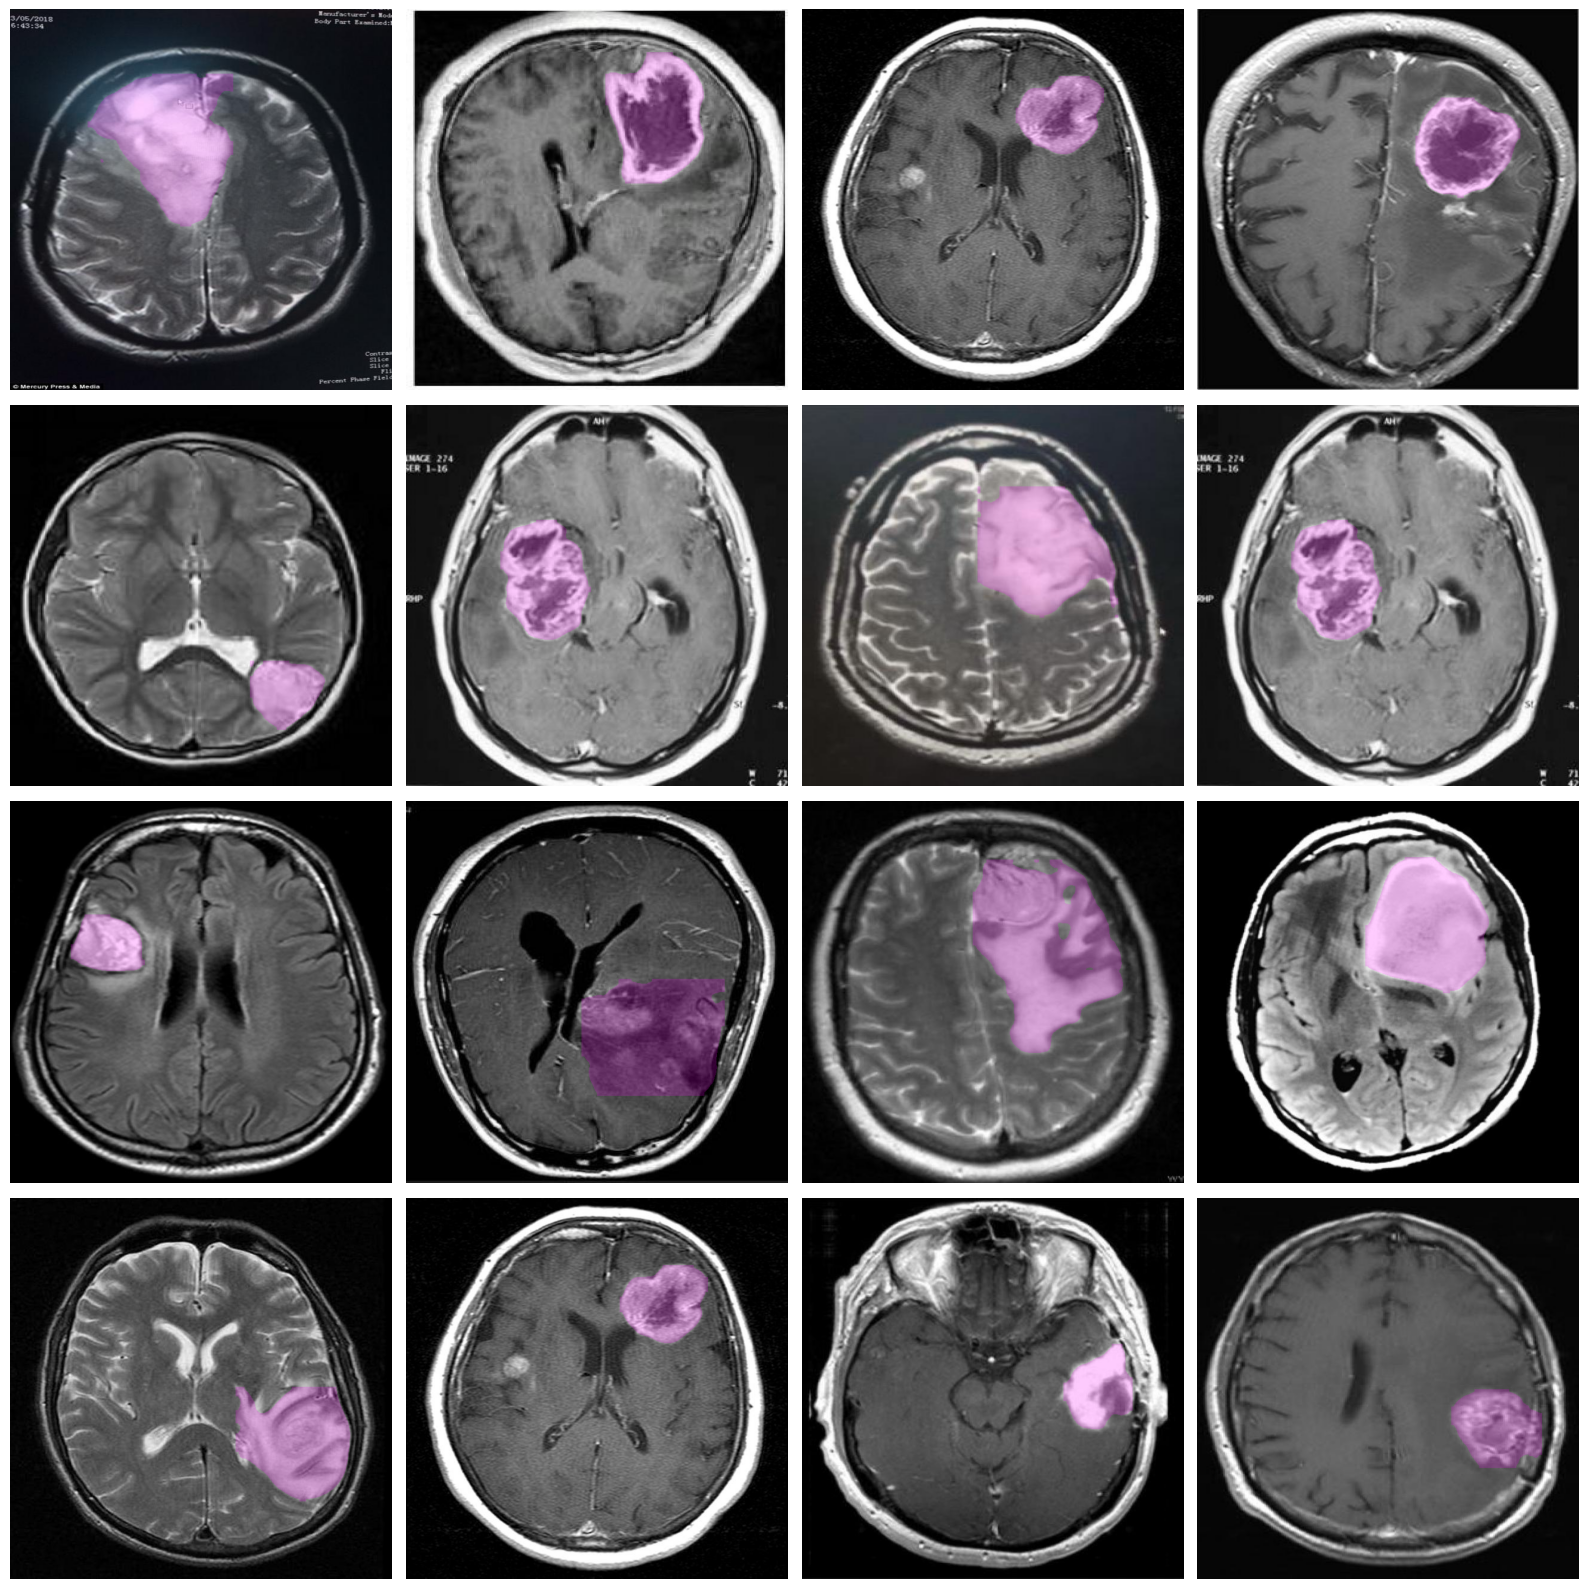

In [11]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import os
import random

# Load trained model
model = YOLO('runs/segment/Brain_Tumor_Segmentation_Datasets_yolov8/weights/best.pt')

# Test images directory
test_images_dir = 'datasets/Brain_Tumor_Segmentation_Datasets/test/images'

# Define colors for visualization
color_sample = {
    0 : (0, 0, 0),
    1 : (255, 0, 255),      # Green
}

image_files = os.listdir(test_images_dir)

# Plot settings
fig, ax = plt.subplots(4, 4, figsize=(16, 16))
ax = ax.ravel()

for idx in range(16):
    img_name = random.choice(image_files)
    img_path = os.path.join(test_images_dir, img_name)
    image = cv2.imread(img_path)
    # Convert BGR to RGB for plotting
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Perform inference
    results = model(img_path)[0]
    # print(results)

    if results.masks:
      # Draw segmentation masks
      for seg in results.masks.data:
          mask = seg.cpu().numpy()
          # Resize mask to match image dimensions
          mask_resized = cv2.resize(mask, (image.shape[1], image.shape[0]))
          image = draw_segmentation(image_rgb, mask_resized, color_sample)

    # Convert BGR to RGB for plotting
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Plot the image
    ax[idx].imshow(image_rgb)
    ax[idx].axis('off')

plt.tight_layout()
plt.show()
